In [2]:
!pip install shap

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB ?  0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   --- ------------------------------------ 3.1/38.1 MB 31.0 MB/s eta 0:00:02
   --- ------------------------------------ 3.1/38.1 MB 31.0 MB/s eta 0:00:02
   --------- ------------------------------ 9.4/38.1 MB 17.8 MB/s eta 0:00:02
   --------- ------------------------------ 9.4/38.1 MB 17.8 MB/s eta 0:00:02
   --------------------- ------------------ 20.4/38.1 MB 19.3 MB/s eta 0:00:01
   --------------------------------- ------ 32.0/38.1 MB 25.1 MB/s eta 0:00:01
   -------------------------------------- - 36.7/38.1 MB 24.8 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 23.5 MB/s  0:00:01
   ---------------------------------------- 0.0/2.7 M

In [3]:
import os
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

c:\Users\301-2\anaconda3\envs\ct_study\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Setup paths
RESULTS_DIR = "../results/shap_outputs"

# === 2. Load model and dataset ===
xgb_final = joblib.load("../models/xgb_pipeline.pkl")
df_final = pd.read_csv("../../data/final/df_final_grouped.csv")

X = df_final.drop(columns=["overall_status", "nct_id", "high_enroll_flag_99"])
y = df_final["overall_status"]

# Encode categorical features
X_encoded = X.copy()
for col in X.select_dtypes("object").columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print("X_test shape:", X_test.shape) 

C:\Users\301-2\AppData\Local\Temp\ipykernel_5240\2839335611.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes("object").columns:


X_test shape: (55753, 21)


In [5]:
# Build SHAP explainer
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer(X_test)

In [7]:
# Bar plot of mean SHAP values
shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=True).reset_index(drop=True)

shap_df.to_csv(os.path.join(RESULTS_DIR, "shap_feature_importance.csv"), index=False)

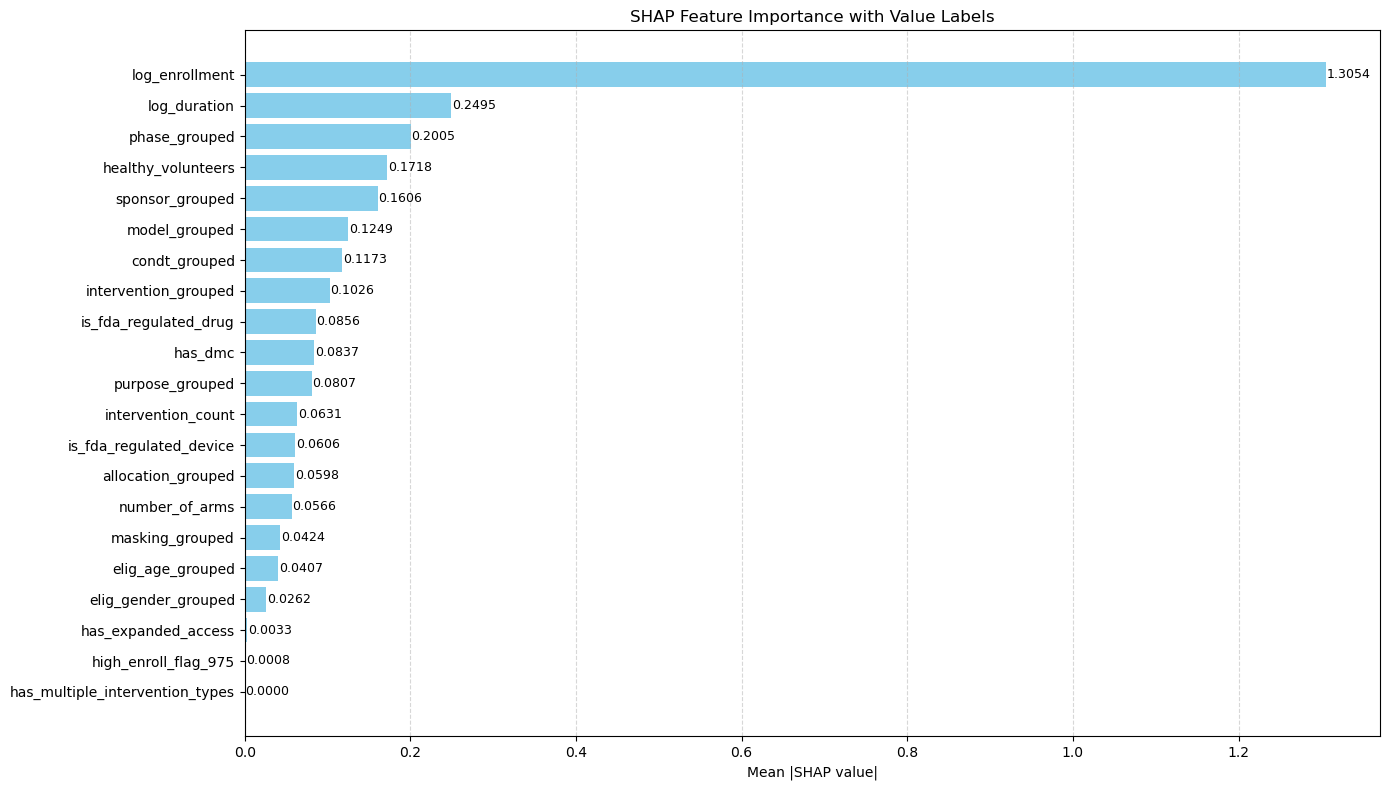

In [8]:
plt.figure(figsize=(14, 8))
bars = plt.barh(shap_df['feature'], shap_df['mean_abs_shap'], color='skyblue')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', va='center', fontsize=9)
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance with Value Labels")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "shap_bar_plot.png"), dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# SHAP Interaction analysis (상호작용분석)
features = [c for c in df_final if c not in ('high_enroll_flag_99', 'nct_id', 
                                             'has_expanded_access', 'overall_status', 
                                             'has_multiple_intervention_types')]
top_interactions = []

# approximate_interactions : shap전체 상호작용행렬(shap_interaction_values) 계산량 어마어마함. 근사치로 빠르게 계산
for feat in features:
    interaction_scores = shap.utils.approximate_interactions(feat, shap_values.values, X_test)
    
    interaction_values = [
        shap_values.values[:, features.index(feat)] * shap_values.values[:, i]
        for i in interaction_scores
    ]
    # 절대값 평균: 상호작용의 방향 관계없이 영향력의 크기 자체에 집중
    mean_interactions = [np.mean(np.abs(val)) for val in interaction_values]  
    interactor_names = [X_test.columns[i] for i in interaction_scores]
    
    top_interactions.append({
        'Main feature': feat,
        'Top interacting feature': interactor_names[0],
        'Top interaction value': round(mean_interactions[0], 3)
    })

df_shap_interactions = pd.DataFrame(top_interactions).sort_values(by='Top interaction value', ascending=False).reset_index(drop=True)
df_shap_interactions.to_csv(os.path.join(RESULTS_DIR, "shap_interacting_features.csv"), index=False)

df_shap_interactions.head(10)

,Main feature,Top interacting feature,Top interaction value
0,log_duration,phase_grouped,0.231
1,is_fda_regulated_device,log_enrollment,0.187
2,elig_age_grouped,log_enrollment,0.176
3,allocation_grouped,log_enrollment,0.123
4,elig_gender_grouped,log_enrollment,0.092
5,model_grouped,log_enrollment,0.087
6,condt_grouped,phase_grouped,0.052
7,purpose_grouped,log_enrollment,0.051
8,high_enroll_flag_975,healthy_volunteers,0.051
9,sponsor_grouped,log_duration,0.039


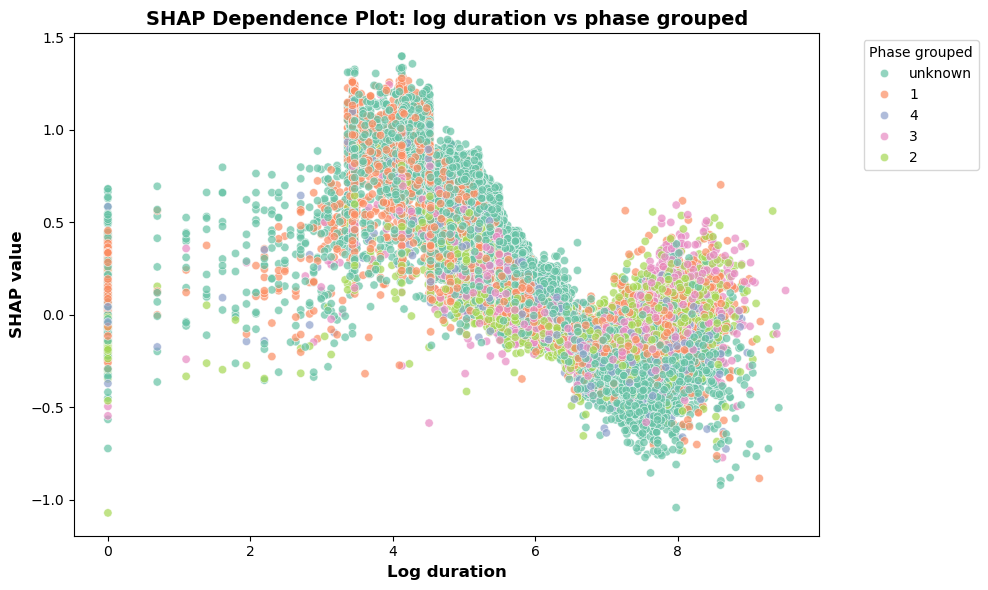

In [10]:
# Dependence plot: log duration vs phase grouped
# 의존성 그래프
le_phase = LabelEncoder()
le_phase.fit(X['phase_grouped']) # 가독성을 위해 숫자 대신 phase 명칭으로

phase_mapping = dict(zip(le_phase.transform(le_phase.classes_), le_phase.classes_))

X_vis = X_test.copy()
X_vis['phase_grouped'] = X_test['phase_grouped'].map(phase_mapping).fillna("Unknown")
shap_val = shap_values.values[:, X_test.columns.get_loc('log_duration')]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_test['log_duration'],
    y=shap_val,
    hue=X_vis['phase_grouped'],
    palette='Set2',
    alpha=0.7
)

plt.xlabel('Log duration', fontsize=12, fontweight='bold')
plt.ylabel('SHAP value', fontsize=12, fontweight='bold')
plt.title('SHAP Dependence Plot: log duration vs phase grouped', fontsize=14, fontweight='bold')
plt.legend(title='Phase grouped', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dep_log_duration_phase.png"), dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Dependence plots for categorical features
# shap 그래프가 숫자로 표현되는 한계를 극복하고 실제 카테고리 이름을 축에 표시하도록 함수화

def shap_dependence_categorical_plot(top_feature, interaction_feature,
                                     shap_values, X_test_encoded, original_df, filename, show=False):
    le = LabelEncoder()
    le.fit(original_df[top_feature])
    mapping = dict(zip(le.transform(le.classes_), le.classes_))

    plt.figure(figsize=(12, 8))
    shap.dependence_plot(
        ind=top_feature,
        shap_values=shap_values.values,
        features=X_test_encoded,
        interaction_index=interaction_feature,
        show=False  
    )
    
    plt.xticks(ticks=list(mapping.keys()),
               labels=list(mapping.values()),
               rotation=45, ha='right', fontsize=10)
    plt.xlabel(top_feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    plt.ylabel("SHAP value", fontsize=12, fontweight='bold')
    plt.title(f"SHAP Dependence Plot: {top_feature.replace('_', ' ')} vs {interaction_feature.replace('_', ' ')}",
              fontsize=14, fontweight='bold')
    plt.tight_layout()

    # Save the plot
    plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=300, bbox_inches="tight")

    # Show the plot only if requested
    if show:
        plt.show()
    else:
        plt.close()

<Figure size 1200x800 with 0 Axes>

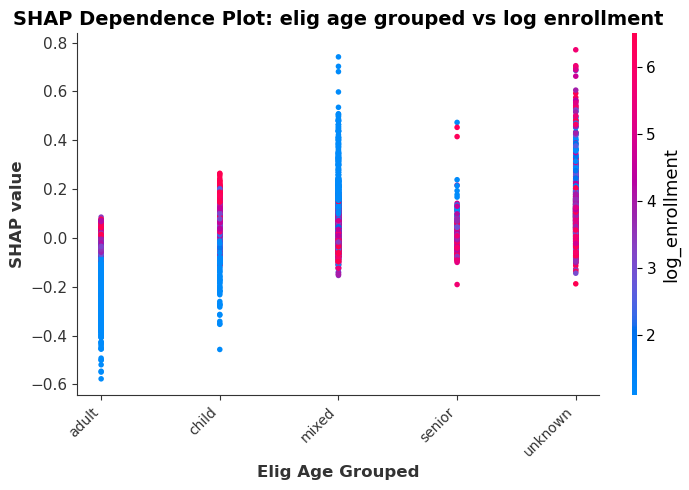

In [12]:
shap_dependence_categorical_plot('elig_age_grouped', 'log_enrollment', shap_values, 
                                 X_test, X, "dep_elig_age_enroll.png", show=True)

<Figure size 1200x800 with 0 Axes>

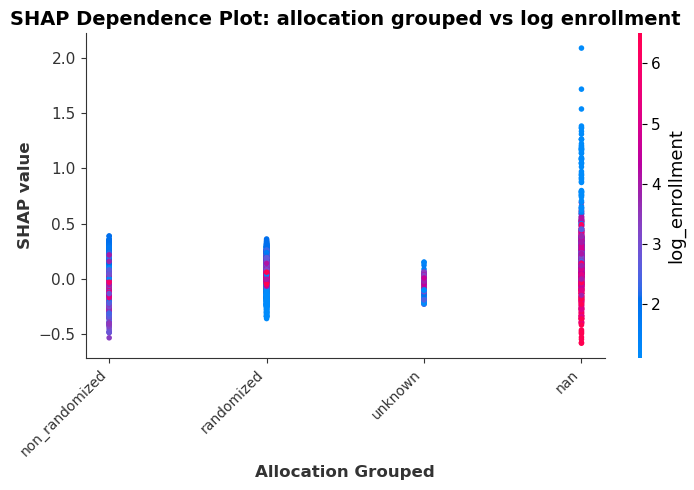

In [13]:
shap_dependence_categorical_plot('allocation_grouped', 'log_enrollment', shap_values, 
                                 X_test, X, "dep_allocation_enroll.png", show=True)

<Figure size 1200x800 with 0 Axes>

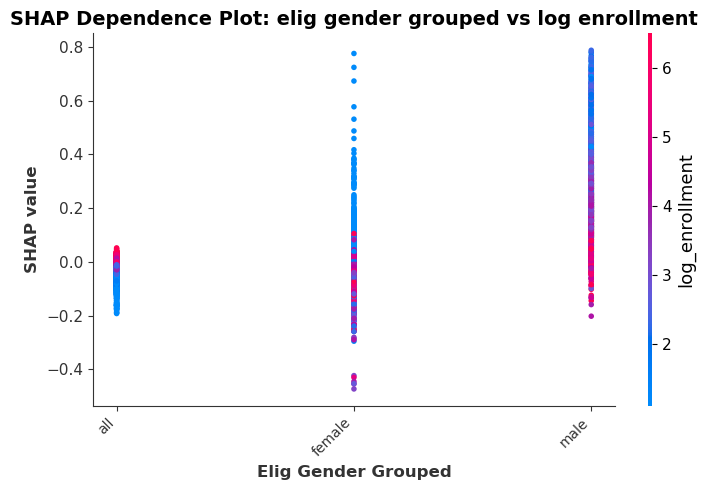

In [14]:
shap_dependence_categorical_plot('elig_gender_grouped', 'log_enrollment', shap_values, 
                                 X_test, X, "dep_elig_gender_enroll.png", show=True)

<Figure size 1200x800 with 0 Axes>

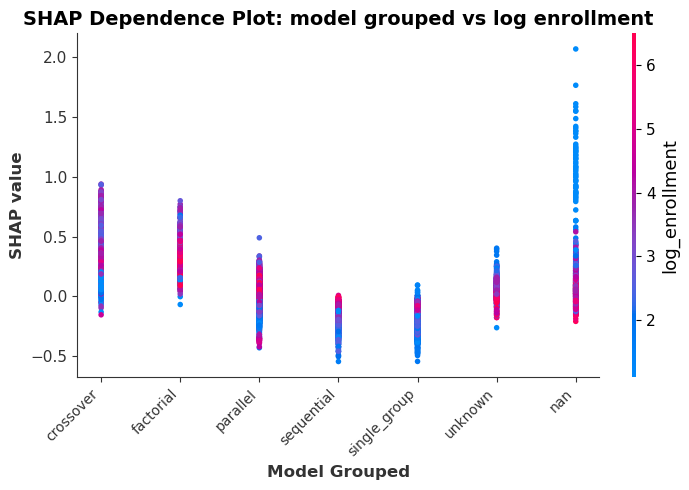

In [15]:
shap_dependence_categorical_plot('model_grouped', 'log_enrollment', shap_values, 
                                 X_test, X, "dep_model_enroll.png", show=True)

<Figure size 1200x800 with 0 Axes>

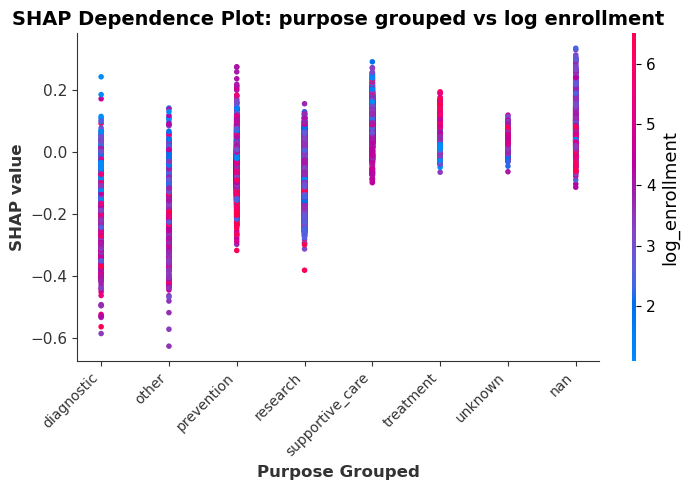

In [16]:
shap_dependence_categorical_plot('purpose_grouped', 'log_enrollment', shap_values, 
                                 X_test, X, "dep_purpose_enroll.png", show=True)

<Figure size 1200x800 with 0 Axes>

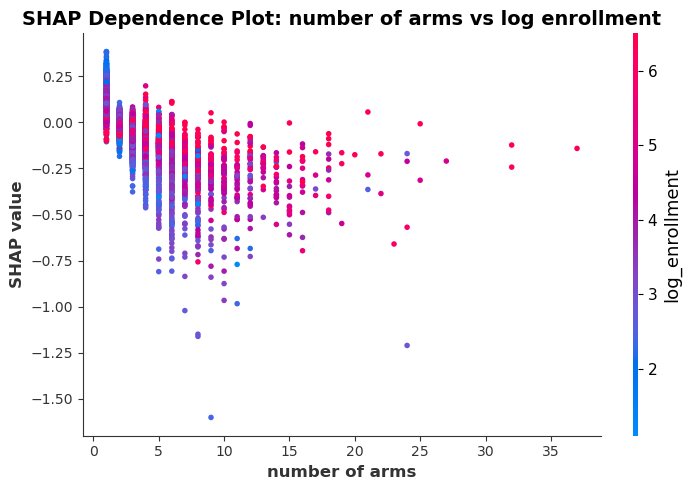

In [17]:
# Numeric dependence plot (arms vs enrollment)
plt.figure(figsize=(12, 8))  

shap.dependence_plot(
    ind='number_of_arms',
    shap_values=shap_values.values,
    features=X_test,
    interaction_index='log_enrollment',
    show=False
)

plt.title('SHAP Dependence Plot: number of arms vs log enrollment', fontsize=14, fontweight='bold')
plt.xlabel('number of arms', fontsize=12, fontweight='bold')
plt.ylabel('SHAP value', fontsize=12, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.savefig(os.path.join(RESULTS_DIR, 'dep_arms_enroll.png'), dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [18]:
# Waterfall plots (success, failure, mid-case)
# 성공확률이 높은경우, 실패확률이 높은경우, 중간인 경우
y_prob = xgb_final.predict_proba(X_test)[:, 1]

# Helper for labeling features with values
# explanation: shape 결과물, decoded_row: 실제값
# 단순히 변수명만 나오는게 아닌 그당시 그변수의 실제값이 무엇이었는지(log_duration)을 함께 표시 
def clean_labels(explanation, decoded_row):
    explanation.feature_names = [
        f"{feat} ({round(decoded_row[feat], 2)})" if isinstance(decoded_row[feat], (int, float))
        else f"{feat} ({decoded_row[feat]})"
        for feat in explanation.feature_names
    ]
    return explanation



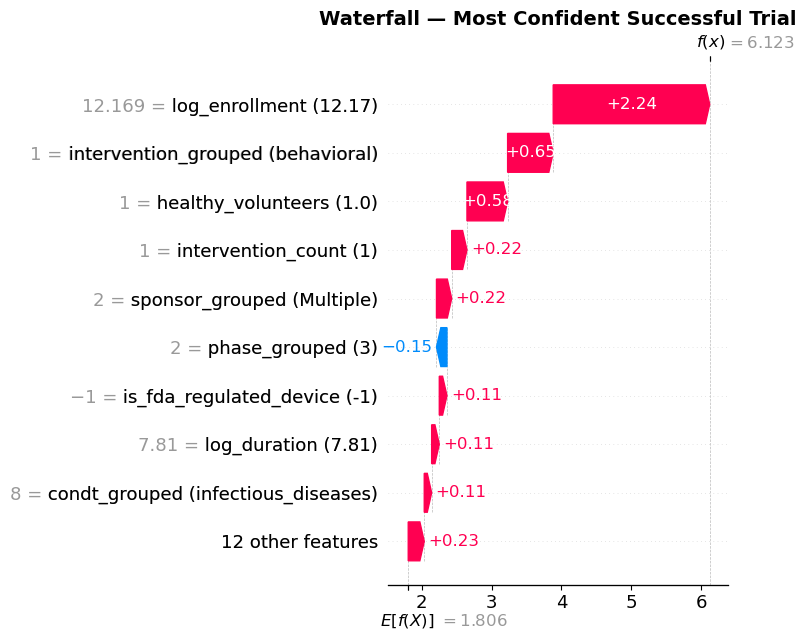

In [19]:
# Success case
success_index = np.argmax(y_prob)
success_expl = explainer(X_test.iloc[success_index:success_index+1])
decoded_row = X.iloc[X_test.index[success_index]]
success_expl_clean = clean_labels(success_expl, decoded_row)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(success_expl_clean[0], show=False)
plt.title("Waterfall — Most Confident Successful Trial", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "waterfall_success.png"), dpi=300, bbox_inches="tight")
plt.show()

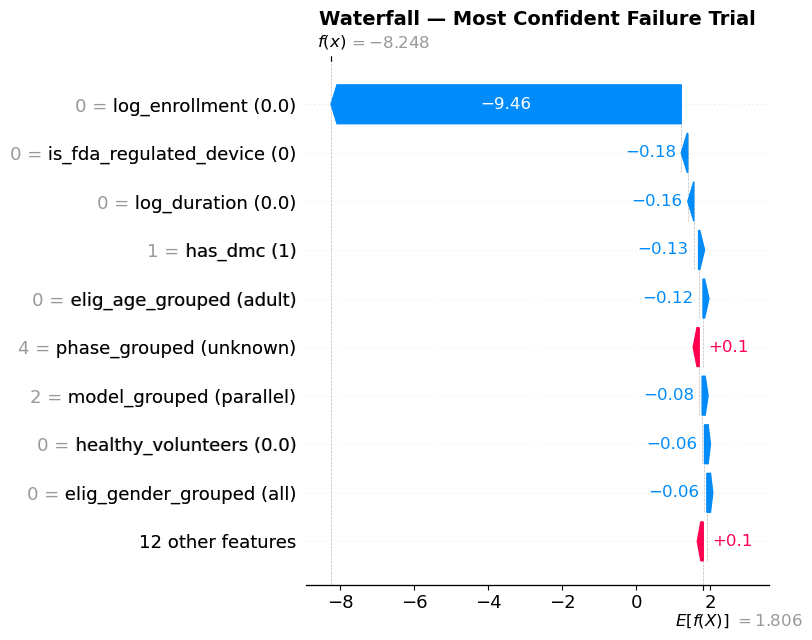

In [20]:
# Failure case
failure_index = np.argmin(y_prob)
failure_expl = explainer(X_test.iloc[failure_index:failure_index+1])
decoded_row = X.iloc[X_test.index[failure_index]]
failure_expl_clean = clean_labels(failure_expl, decoded_row)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(failure_expl_clean[0], show=False)
plt.title("Waterfall — Most Confident Failure Trial", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "waterfall_failure.png"), dpi=300, bbox_inches="tight")
plt.show()

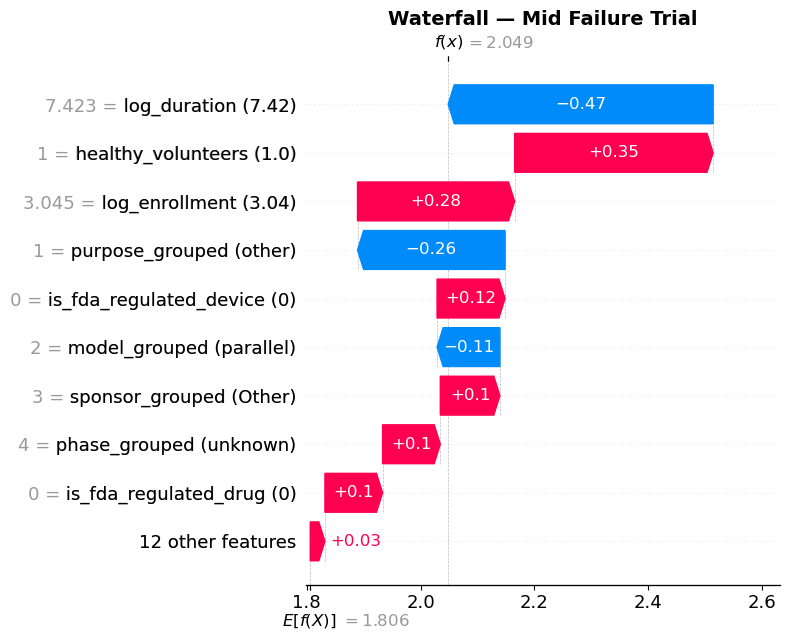

In [21]:
# Mid-case failure (25th percentile)
sorted_preds = np.argsort(y_prob)  # ascending
mid_failure_index = sorted_preds[len(sorted_preds) // 4]

mid_failure_expl = explainer(X_test.iloc[mid_failure_index:mid_failure_index+1])
decoded_row = X.iloc[X_test.index[mid_failure_index]]
mid_failure_expl_clean = clean_labels(mid_failure_expl, decoded_row)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(mid_failure_expl_clean[0], show=False)
plt.title("Waterfall — Mid Failure Trial", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "waterfall_mid_failure.png"), dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# shap explainer 객체 저장
explainer_xgb = shap.TreeExplainer(xgb_final)
joblib.dump(explainer_xgb, "../models/shap_explainer_xgb.pkl")

['../models/shap_explainer_xgb.pkl']